In [ ]:
%%sql


In [6]:
import pandas as pd
import torch

from src.real_world.preprocess_real import prepare_real_dataset
from src.real_world.train_mlp_real import train_mlp_real


from src.metrics.evaluation import evaluate_model

from src.metrics.visualize_fairness import evaluate_fairness

from src.metrics.visualize_fairness import plot_equal_opportunity


In [3]:
df = pd.read_csv("diabetes_dataset.csv")
data = prepare_real_dataset(df)

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
sens_test = data["sens_test"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nSensitive attribute counts:")
print(sens_test["gender"].value_counts())
print(sens_test["race"].value_counts())

Train shape: (69987, 12)
Test shape: (29995, 12)

Sensitive attribute counts:
gender
Female    17543
Male      12452
Name: count, dtype: int64
race
AfricanAmerican    6113
Caucasian          6060
Asian              6004
Hispanic           5933
Other              5885
Name: count, dtype: int64


Epoch 1/20 | Train Loss 0.1364, Acc 0.9498 | Val Loss 0.1086, Acc 0.9631
Epoch 2/20 | Train Loss 0.1010, Acc 0.9647 | Val Loss 0.0982, Acc 0.9675
Epoch 3/20 | Train Loss 0.0918, Acc 0.9683 | Val Loss 0.0919, Acc 0.9691
Epoch 4/20 | Train Loss 0.0866, Acc 0.9696 | Val Loss 0.0908, Acc 0.9694
Epoch 5/20 | Train Loss 0.0840, Acc 0.9710 | Val Loss 0.0864, Acc 0.9707
Epoch 6/20 | Train Loss 0.0830, Acc 0.9713 | Val Loss 0.0859, Acc 0.9704
Epoch 7/20 | Train Loss 0.0823, Acc 0.9716 | Val Loss 0.0858, Acc 0.9708
Epoch 8/20 | Train Loss 0.0823, Acc 0.9717 | Val Loss 0.0856, Acc 0.9712
Epoch 9/20 | Train Loss 0.0819, Acc 0.9716 | Val Loss 0.0850, Acc 0.9712
Epoch 10/20 | Train Loss 0.0816, Acc 0.9718 | Val Loss 0.0850, Acc 0.9715
Epoch 11/20 | Train Loss 0.0813, Acc 0.9717 | Val Loss 0.0854, Acc 0.9717
Epoch 12/20 | Train Loss 0.0812, Acc 0.9718 | Val Loss 0.0858, Acc 0.9717
Epoch 13/20 | Train Loss 0.0811, Acc 0.9720 | Val Loss 0.0884, Acc 0.9700
Epoch 14/20 | Train Loss 0.0809, Acc 0.9720 | V

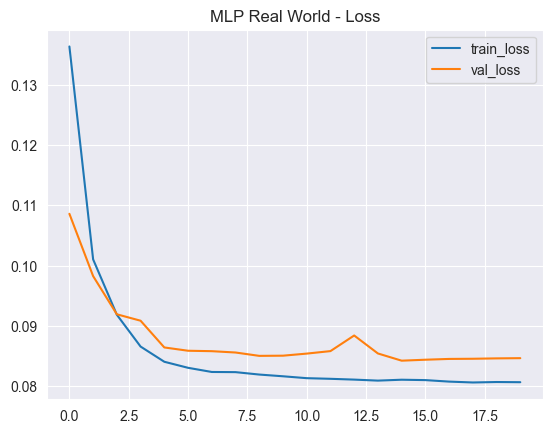

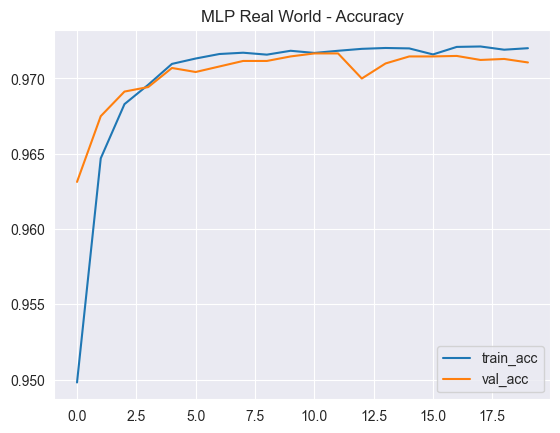


===== Neural Network Performance =====
Accuracy: 0.9710618436406068


In [4]:
nn_output = train_mlp_real(
    X_train_s=X_train,
    y_train=y_train,
    X_test_s=X_test,
    y_test=y_test,
    input_dim=X_train.shape[1],
    n_epochs=20,
    lr=0.001,
    plot_training=True
)

y_pred_nn = nn_output["y_pred"]

print("\n===== Neural Network Performance =====")
print("Accuracy:", nn_output["accuracy"])

In [10]:
fair_results_nn = evaluate_model(y_test.values, y_pred_nn, sens_test)


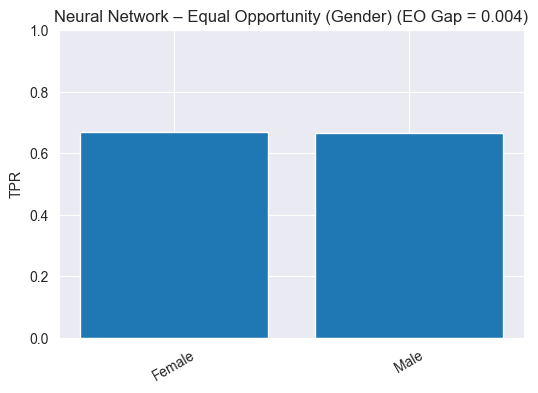

In [14]:
plot_equal_opportunity(
    fair_results_nn["gender_tprs"],
    title="Neural Network – Equal Opportunity (Gender)"
)


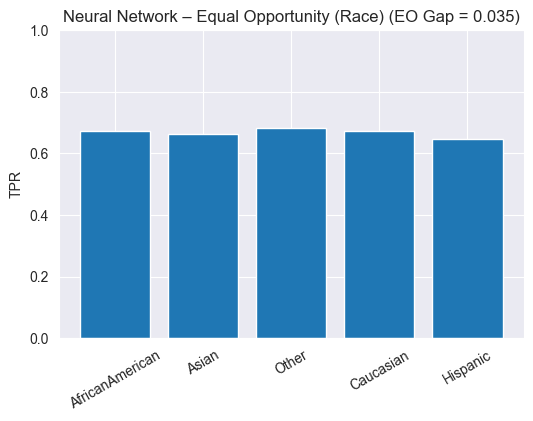

In [15]:
plot_equal_opportunity(
    fair_results_nn["race_tprs"],
    title="Neural Network – Equal Opportunity (Race)"
)



===== NEURAL NETWORK FAIRNESS =====
Accuracy: 0.9710618436406068
Precision: 0.9883855981416957
Recall: 0.6674509803921569

--- Gender TPRs ---
{'Female': 0.6692248656945511, 'Male': 0.6655974338412189}
EO Gap (Gender): 0.0036274318533321415

--- Race TPRs ---
{'AfricanAmerican': 0.6738738738738739, 'Asian': 0.6640471512770137, 'Other': 0.6817204301075269, 'Caucasian': 0.6711538461538461, 'Hispanic': 0.6467065868263473}
EO Gap (Race): 0.035013843281179624


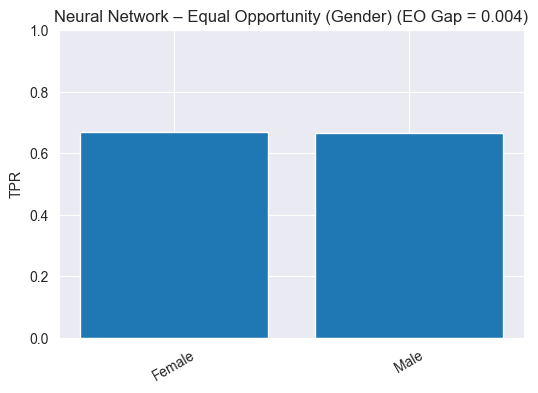

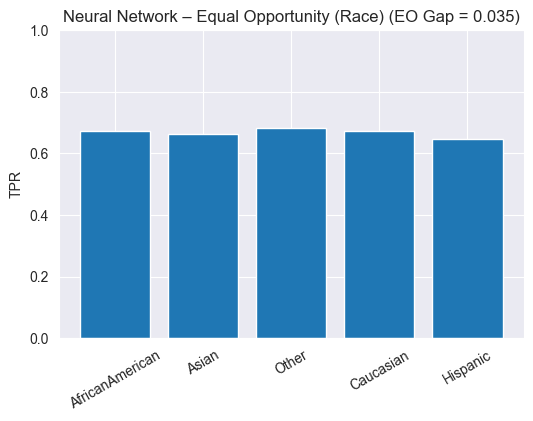

In [16]:
print("\n===== NEURAL NETWORK FAIRNESS =====")
print("Accuracy:", fair_results_nn["accuracy"])
print("Precision:", fair_results_nn["precision"])
print("Recall:", fair_results_nn["recall"])

print("\n--- Gender TPRs ---")
print(fair_results_nn["gender_tprs"])
print("EO Gap (Gender):", fair_results_nn["gender_gap"])

print("\n--- Race TPRs ---")
print(fair_results_nn["race_tprs"])
print("EO Gap (Race):", fair_results_nn["race_gap"])

# === EO Plots ===
plot_equal_opportunity(
    fair_results_nn["gender_tprs"],
    title="Neural Network – Equal Opportunity (Gender)"
)

plot_equal_opportunity(
    fair_results_nn["race_tprs"],
    title="Neural Network – Equal Opportunity (Race)"
)
